In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal.windows import nuttall
from matplotlib.colors import LogNorm
import pkfuncs as pfunc
import scipy
from scipy.signal import windows
import plot_scripts as plts
import os
plt.style.use("mplstyle")

In [2]:
# input model power spectrum
n = 2.0
N = 768
dnuc = 40e-3            # MHz
r = 9209.714526830916 # Mpc
rp = 16.98990953034521  # Mpc/MHz
dL = dnuc * rp
L  = N * dL
Nrea = 100
nua = np.load('nua.npy')
dnu = np.arange(N)*dnuc

k_model = np.logspace(-4, 4, 5000)
P_model = k_model**(-n)

# EoR 21-cm PS for Mondal+17
PK21 = np.load('PK21.npy')
k_model = PK21[:, 0]
P_model = PK21[:, 1]


k_fft = 2*np.pi*np.arange(N)/L
k_abs = np.abs(k_fft)

P_cont = np.interp(k_abs, k_model, P_model , left=0, right=0)

# Discrete variance for FFT modes
P_dft = (N**2 / L) * P_cont 

# k_model = k_abs
# P_model = P_dft

# binning 
NB = 64  # number of bins


In [3]:
path = 'data'
os.makedirs(path, exist_ok=True)
os.makedirs('plots', exist_ok=True)

In [4]:
INP_SIGNAL_CONFIGS = {
    "21cm": dict(type="21cm"),
    "FG+21cm": dict(type="FG+21cm"),
    "FG+MM+21cm": dict(type="FG+MM+21cm"),
}


# -----------------------------
# FLAG configurations
# -----------------------------
FLAG_CONFIGS = {
    "NOFLAG": dict(mode="NOFLAG", percent=0, seed=42),
    "RANDOM35": dict(mode="RANDOM", percent=35, seed=42),
    "PERIODIC": dict(mode="PERIODIC", percent=0, seed=42),
    "PERIODIC+RANDOM10": dict(mode="PERIODIC+RANDOM", percent=10, seed=42),
}



In [5]:
inp_signal = '21cm'
# fields_21cm = generate_fields(inp_signal=inp_signal, N=N, Nrea=Nrea, P_dft=P_dft)
fields_21cm = np.array(
        [pfunc.draw_field_from_power(P_dft, seed=55 + i) for i in range(Nrea)]
    )
np.save(f'{path}/21cm.npy', fields_21cm)


In [6]:
fields_forg1 = pfunc.generate_gp_realizations(
            Npoints=N,
            amplitude=1e12,
            length_scale=1e4,
            Nreal=Nrea,
            kernel_type="RBF",
            sigma=1, seed=42,
        )

np.save(f'{path}/FG+21cm.npy', fields_forg1)


fields_forg2 = pfunc.generate_gp_realizations(
            Npoints=N,
            amplitude=1e12,
            length_scale=1e2,
            Nreal=Nrea,
            kernel_type="RBF",
            sigma=1, seed=42,
        )

np.save(f'{path}/FG+MM+21cm.npy', fields_forg2)

In [7]:
for flag_key, flag_cfg in FLAG_CONFIGS.items():

    flag = pfunc.flagdata(
        N,
        mode=flag_cfg["mode"],
        percent=flag_cfg["percent"],
        seed=flag_cfg["seed"],
    )
    
    np.save(f'{path}/{flag_cfg["mode"]}.npy',flag)


In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Length scales
ell1 = 1e4*dnuc   # smooth FG
ell2 = 1e2*dnuc   # structured FG

# RBF covariance (normalised)
K1 = 1e0 * np.exp(-0.5 * (dnu / ell1)**2)
K2 = 1e0 * np.exp(-0.5 * (dnu / ell2)**2)


from sklearn.gaussian_process.kernels import RBF

def get_kernel_matrix(Npoints, amplitude, length_scale, dnuc):
    x = np.arange(Npoints)[:, None]*dnuc
    kernel = amplitude * RBF(length_scale=length_scale)
    K = kernel(x, x)   # this is the covariance matrix
    return K


amplitude = 1e0
K1 = get_kernel_matrix(N, amplitude, ell1, dnuc) # 1e0 * RBF(length_scale=ell1)
K2 = get_kernel_matrix(N, amplitude, ell2, dnuc) # 1e0 * RBF(length_scale=ell2)


In [9]:
from scipy import integrate
def pk_intp(kv, karr, pkarr): # kv, k-array , pk-array
    y = np.interp(np.log(kv), np.log(karr), np.log(pkarr))
    return np.exp(y) # np.interp(kv, karr, pkarr)


def pk2cl(x, rp, dn, kp, dnuc, karr, pkarr): # x: kpara-array, dn: ndnu, kp:kper, dnuc:dnuc.
    kv = np.sqrt(kp**2 + x**2)
    y = np.cos(x*rp*dn) * pk_intp(kv, karr, pkarr) * np.power(np.sinc(x*rp*dnuc/(2.*np.pi)), 2.) 
    # less than 1% change at dnu=0 when sinc is omitted.
    return y

    
cl21 = np.zeros(N)
x = np.linspace(0, 5, 2*N)
for jj in range(N):
    cl21[jj] = integrate.simpson(pk2cl(x, rp, dnu[jj], 0., dnuc, k_model, P_model), x)/(np.pi*r**2)

# np.save('cl21_discrete.npy', cl21)
np.save('cl21.npy', cl21)
cl_norm = cl21/cl21[0]
# plt.plot(cl_norm)
# plt.show()

from scipy.linalg import toeplitz
COV21 = toeplitz(cl_norm)

# plt.pcolormesh(dnu, dnu, COV21)
# plt.show()


/tmp/ipykernel_4088552/3278001420.py:3: RuntimeWarning: divide by zero encountered in log
  y = np.interp(np.log(kv), np.log(karr), np.log(pkarr))


In [10]:
2*np.pi/(rp*4), 2*np.pi/(rp*3), 2*np.pi/(rp*2), 
2*np.pi/(rp*4), 2*np.pi/(rp*3), 2*np.pi/(rp*2), 

(0.09245466104391789, 0.12327288139189053, 0.18490932208783578)

In [11]:
2*np.pi/(rp*0.09), 2*np.pi/(rp*0.135), 2*np.pi/(rp*0.185)

(4.109096046396351, 2.7393973642642337, 1.9990196982468733)

In [12]:
def hwhm(dnu, corr, target = 0.5):
    """
    Half-width at half-maximum for a monotonic correlation function.
    Assumes corr[0] = 1 and corr decreases with dnu.
    """
    
    # Find first index where correlation drops below 0.5
    idx = np.where(corr <= target)[0]

    if len(idx) == 0:
        return np.nan  # never crosses 0.5

    i = idx[0]

    # Linear interpolation between neighbouring points
    x1, x2 = dnu[i-1], dnu[i]
    y1, y2 = corr[i-1], corr[i]

    return x1 + (target - y1) * (x2 - x1) / (y2 - y1)

def annotate_hwhm_and_eighty(ax, hwhm, eighty, y=0.05):
    """
    Annotate HWHM (50%) and 80% fall (20%) on an axis.
    Values are placed on the x-axis using axis coordinates.
    """
    ax.text(
        hwhm, y, f'{hwhm:.2f}',
        transform=ax.get_xaxis_transform(),
        ha='right', va='bottom',
        fontsize=9, color='k'
    )

    ax.text(
        eighty, y, f'{eighty:.2f}',
        transform=ax.get_xaxis_transform(),
        ha='right', va='bottom',
        fontsize=9, color='r'
    )

from matplotlib.lines import Line2D

def add_hwhm_legend(ax, hwhm, eighty, loc='upper right', fontsize=12):
    """
    Add a legend showing 50% (HWHM) and 20% (80% fall) Δν values
    for a given panel.
    """
    legend_handles = [
        Line2D(
            [0], [0], ls='--', color='k', lw=1,
            label=r'\rm{50\% at $\Delta\nu = $}' + f' {hwhm:.2f} MHz'
        ),
        Line2D(
            [0], [0], ls='--', color='r', lw=1,
            # label=r'\rm{{20\% \ at\ \Delta\nu}} = {eighty:.2f}\ MHz'
            label=r'\rm{20\% at $\Delta\nu = $}' + f' {eighty:.2f} MHz'
        ),
    ]

    ax.legend(
        handles=legend_handles,
        frameon=True,
        fontsize=fontsize,
        loc=loc
    )


HWHM (Δν): 21-cm = 1.00 MHz, smooth FG = nan MHz, structured FG = 4.71 MHz
80% (Δν): 21-cm = 1.91 MHz, smooth FG = nan MHz, structured FG = 7.18 MHz


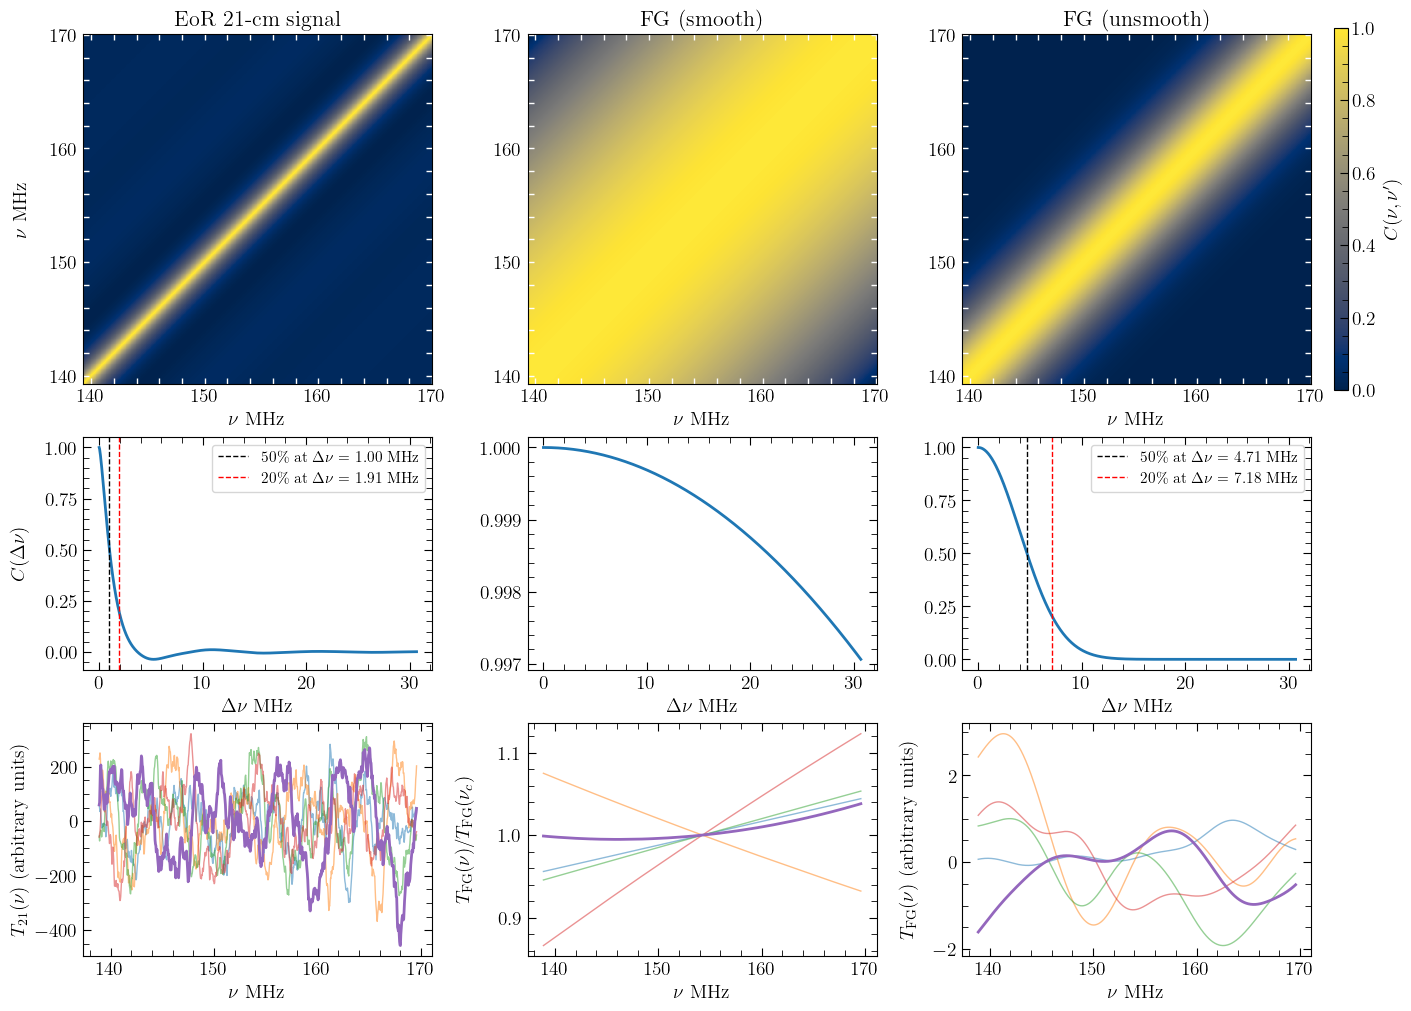

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Controls
# --------------------------------------------------
nplot = 5
lw_main = 2
lw_sec  = 1
alpha_sec = 0.5

freq = np.load('nua.npy') / 1e6  # MHz
rng  = np.random.default_rng(20)
idx  = rng.choice(Nrea, size=nplot, replace=False)

# --------------------------------------------------
# Figure layout: 3 rows × 4 columns (last for colorbar)
# --------------------------------------------------
fig = plt.figure(figsize=(14, 10), constrained_layout=True)

gs = fig.add_gridspec(
    3, 4,
    width_ratios=[1, 1, 1, 0.04],
    height_ratios=[1.4, 0.9, 0.9],
    wspace=0.01,
    hspace=0.01
)


axes = np.empty((3, 3), dtype=object)
for i in range(3):
    for j in range(3):
        axes[i, j] = fig.add_subplot(gs[i, j])

# ==================================================
# ROW 1: Covariance matrices
# ==================================================
pcm0 = axes[0, 0].pcolormesh(freq+0.44, freq+0.44, COV21, shading='auto', rasterized=True, cmap='cividis')
pcm1 = axes[0, 1].pcolormesh(freq+0.44, freq+0.44, K1,    shading='auto', rasterized=True, cmap='cividis')
pcm2 = axes[0, 2].pcolormesh(freq+0.44, freq+0.44, K2,    shading='auto', rasterized=True, cmap='cividis')

# Column titles (ONLY here)
axes[0, 0].set_title(r'\rm{EoR\ 21-cm\ signal}', pad=6)
axes[0, 1].set_title(r'\rm{FG\ (smooth)}', pad=6)
axes[0, 2].set_title(
    r'\rm{FG\ (unsmooth)}',
    pad=6
)

# nticks = 5  # choose any reasonable number

# tick_vals = np.linspace(freq.min(), freq.max(), nticks)
tick_vals = np.array([140, 150, 160, 170])

for j in range(3):
    axes[0, j].set_xticks(tick_vals)
    axes[0, j].set_yticks(tick_vals)
# for j in range(1, 3):
#     axes[0, j].tick_params(labelleft=False)



for j in range(3):
    # axes[0, j].set_xlabel(r'$\rm{\Delta\nu\ [MHz]}$')
    
    axes[0, j].set_aspect('equal')
    axes[0, j].set_xlabel(r'$\nu$ \rm{MHz}')
axes[0, 0].set_ylabel(r'$\nu$ \rm{MHz}')

# Colorbar (dedicated column)
cax = fig.add_subplot(gs[0, 3])
cbar = fig.colorbar(pcm2, cax=cax)
cbar.set_label(r'$C(\nu, \nu^{\prime})$')


for j in range(3):
    axes[0, j].tick_params(
        axis='both',
        which='both',
        color='white',   # tick marks
        labelcolor='k',
        width=1.0,
        length=4
    )




# ==================================================
# ROW 2: Normalised covariance vs Δν
# ==================================================
Kdiag_smooth = K1[0, :]
Kdiag_smooth_norm = Kdiag_smooth/Kdiag_smooth[0]
Kdiag_struct = K2[0, :]
Kdiag_struct_norm = Kdiag_struct/Kdiag_struct[0]

cl21_discrete = np.load('cl21_discrete.npy')
cl21_discrete_norm = cl21_discrete/cl21_discrete[0]

hwhm_21     = hwhm(dnu, cl_norm)
hwhm_smooth = hwhm(dnu, Kdiag_smooth_norm)
hwhm_struct = hwhm(dnu, Kdiag_struct_norm)

eighty_21     = hwhm(dnu, cl_norm, target=0.2)
eighty_smooth = hwhm(dnu, Kdiag_smooth_norm, target=0.2)
eighty_struct = hwhm(dnu, Kdiag_struct_norm, target=0.2)


print(
    f'HWHM (Δν): '
    f'21-cm = {hwhm_21:.2f} MHz, '
    f'smooth FG = {hwhm_smooth:.2f} MHz, '
    f'structured FG = {hwhm_struct:.2f} MHz'
)


print(
    f'80% (Δν): '
    f'21-cm = {eighty_21:.2f} MHz, '
    f'smooth FG = {eighty_smooth:.2f} MHz, '
    f'structured FG = {eighty_struct:.2f} MHz'
)


axes[1, 0].plot(dnu, cl_norm, lw=2)
axes[1, 0].axvline(hwhm_21, ls='--', color='k', lw=1)
axes[1, 0].axvline(eighty_21, ls='--', color='r', lw=1)

axes[1, 1].plot(dnu, Kdiag_smooth_norm, lw=2)
axes[1, 1].axvline(hwhm_smooth, ls='--', color='k', lw=1)
axes[1, 1].axvline(eighty_smooth, ls='--', color='r', lw=1)

axes[1, 2].plot(dnu, Kdiag_struct_norm, lw=2)
axes[1, 2].axvline(hwhm_struct, ls='--', color='k', lw=1)
axes[1, 2].axvline(eighty_struct, ls='--', color='r', lw=1)


# annotate_hwhm_and_eighty(axes[1, 0], hwhm_21,     eighty_21)
# annotate_hwhm_and_eighty(axes[1, 1], hwhm_smooth, eighty_smooth)
# annotate_hwhm_and_eighty(axes[1, 2], hwhm_struct, eighty_struct)

add_hwhm_legend(axes[1, 0], hwhm_21,     eighty_21, fontsize=11)
# add_hwhm_legend(axes[1, 1], hwhm_smooth, eighty_smooth)
add_hwhm_legend(axes[1, 2], hwhm_struct, eighty_struct, fontsize=11)





for j in range(3):
    axes[1, j].set_xlabel(r'$\Delta\nu$ \rm{MHz}')
axes[1, 0].set_ylabel(r'$C(\Delta\nu)$')


# ==================================================
# ROW 3: Random realisations
# ==================================================
# (a) 21-cm
for k, i in enumerate(idx):
    lw = lw_main if k == (nplot-1) else lw_sec
    alpha = 1.0 if k == (nplot-1) else alpha_sec
    axes[2, 0].plot(freq, fields_21cm[i], lw=lw, alpha=alpha)

axes[2, 0].set_ylabel(
    r'$T_{21}(\nu)$' + r'\rm{\ (arbitrary\ units)}'
)

# (b) Smooth FG
for k, i in enumerate(idx):
    lw = lw_main if k == (nplot-1) else lw_sec
    alpha = 1.0 if k == (nplot-1) else alpha_sec
    fg = fields_forg1[i]
    axes[2, 1].plot(freq, fg / fg[N//2], lw=lw, alpha=alpha)

axes[2, 1].set_ylabel(
    r'$T_{\mathrm{FG}}(\nu) / T_{\mathrm{FG}}(\nu_c)$'
)

# (c) Structured FG
for k, i in enumerate(idx):
    lw = lw_main if k == (nplot-1) else lw_sec
    alpha = 1.0 if k == (nplot-1) else alpha_sec
    fg = fields_forg2[i] / 1e6
    axes[2, 2].plot(freq, fg, lw=lw, alpha=alpha)

axes[2, 2].set_ylabel(
    r'$T_{\mathrm{FG}}(\nu) \ \rm{(arbitrary\ units)}$'
)

for j in range(3):
    axes[2, j].set_xlabel(r'$\rm{\nu\ MHz}$')

# --------------------------------------------------
# Save
# --------------------------------------------------
fig.align_ylabels()
plt.savefig('plots/fg_eor_cov_realizations.pdf', dpi=300, bbox_inches='tight')
plt.show()


In [14]:
freq[0], freq[-1], np.average(freq)

(np.float64(138.895008), np.float64(169.575008), np.float64(154.235008))

In [15]:
# import numpy as np
# import matplotlib.pyplot as plt

# # --------------------------------------------------
# # Load data
# # --------------------------------------------------
# path = "data"
# freq = np.load("nua.npy") / 1e6  # MHz

# flag_periodic = np.load(f"{path}/PERIODIC.npy").astype(bool)
# flag_prandom  = np.load(f"{path}/PERIODIC+RANDOM.npy").astype(bool)
# flag_random   = np.load(f"{path}/RANDOM.npy").astype(bool)

# # --------------------------------------------------
# # Select central 64 channels
# # --------------------------------------------------
# Nchan = freq.size
# Nc = 130
# i0 = Nchan // 2 - Nc // 2
# i1 = Nchan // 2 + Nc // 2

# freq_c = freq[i0:i1]

# # --------------------------------------------------
# # Figure: 3 × 1 panels (vertical)
# # --------------------------------------------------
# fig, axes = plt.subplots(
#     3, 1,
#     figsize=(14, 6.0),
#     sharex=True,
#     constrained_layout=True,
#     facecolor='white'
# )

# cases = [
#     (flag_periodic[i0:i1],  r"{\rm PERIODIC}"),
#     (flag_prandom[i0:i1],   r"{\rm PERIODIC + RANDOM}"),
#     (flag_random[i0:i1],    r"{\rm RANDOM}"),
# ]

# for ax, (flag, title) in zip(axes, cases):

#     # Unflagged channels – light grey
#     ax.vlines(freq_c[flag], 0, 1, lw=1, color='C0')

#     # Flagged channels – red
#     ax.vlines(freq_c[~flag], 0, 1, lw=0.5, alpha=0.2, color='C3')

#     ax.set_title(title, pad=4)
#     ax.set_xlim(freq_c.min(), freq_c.max())
#     # ax.set_ylim(0, 1)

#     ax.tick_params(direction='in', top=True, right=True)

# axes[1].set_ylabel(r'$\rm{Flag\ mask}$')
# axes[-1].set_xlabel(r'$\rm{\nu\ [MHz]}$')

# plt.savefig("plots/flagging.pdf", dpi=300)
# plt.show()


In [16]:
# import numpy as np
# import matplotlib.pyplot as plt

# # --------------------------------------------------
# # Load data
# # --------------------------------------------------
# path = "data"
# freq = np.load("nua.npy") / 1e6  # MHz

# flag_periodic = np.load(f"{path}/PERIODIC.npy").astype(bool)
# flag_prandom  = np.load(f"{path}/PERIODIC+RANDOM.npy").astype(bool)
# flag_random   = np.load(f"{path}/RANDOM.npy").astype(bool)

# # --------------------------------------------------
# # Select central 130 channels
# # --------------------------------------------------
# Nchan = freq.size
# Nc = 130
# Nc = Nchan  
# i0 = Nchan // 2 - Nc // 2
# i1 = Nchan // 2 + Nc // 2

# freq_c = freq[i0:i1]

# # --------------------------------------------------
# # Figure: 3 × 1 panels (vertical)
# # --------------------------------------------------
# fig, axes = plt.subplots(
#     3, 1,
#     figsize=(20, 6.0),
#     sharex=True,
#     constrained_layout=True,
#     facecolor='white'
# )

# cases = [
#     (flag_periodic[i0:i1],  r"{\rm PERIODIC}"),
#     (flag_prandom[i0:i1],   r"{\rm PERIODIC + RANDOM}"),
#     (flag_random[i0:i1],    r"{\rm RANDOM}"),
# ]

# for ax, (flag, title) in zip(axes, cases):

#     # Unflagged channels – blue
#     ax.vlines(freq_c[flag], 0, 1, lw=1.5, color='C0')

#     # Flagged channels – red
#     ax.vlines(freq_c[~flag], 0, 1, lw=0.5, alpha=0.5, color='C3')

#     ax.set_title(title, pad=4)
#     ax.set_xlim(freq_c.min()-0.04, freq_c.max()+0.04)

#     # ---- remove y-axis ----
#     ax.set_yticks([])
#     ax.set_ylabel('')
#     # ax.spines['left'].set_visible(False)

#     ax.tick_params(direction='in', top=True, right=True)

# axes[-1].set_xlabel(r'$\rm{\nu\ [MHz]}$')

# plt.savefig("plots/flagging.pdf", dpi=600, bbox_inches="tight")
# plt.show()


In [17]:
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib.colors import ListedColormap

# # --------------------------------------------------
# # Load data
# # --------------------------------------------------
# path = "data"
# freq = np.load("nua.npy") / 1e6  # MHz

# flag_periodic = np.load(f"{path}/PERIODIC.npy").astype(bool)
# flag_prandom  = np.load(f"{path}/PERIODIC+RANDOM.npy").astype(bool)
# flag_random   = np.load(f"{path}/RANDOM.npy").astype(bool)

# # --------------------------------------------------
# # Select central channels
# # --------------------------------------------------
# Nchan = freq.size
# Nc = Nchan
# i0 = Nchan // 2 - Nc // 2
# i1 = Nchan // 2 + Nc // 2

# freq_c = freq[i0:i1]

# # --------------------------------------------------
# # Figure: 3 × 1 panels
# # --------------------------------------------------
# fig, axes = plt.subplots(
#     3, 1,
#     figsize=(16, 6.0),
#     sharex=True,
#     constrained_layout=True,
#     facecolor='white'
# )

# cases = [
#     (flag_periodic[i0:i1],  r"{\rm PERIODIC}"),
#     (flag_prandom[i0:i1],   r"{\rm PERIODIC + RANDOM}"),
#     (flag_random[i0:i1],    r"{\rm RANDOM}"),
# ]

# # Colormap: flagged (False) → red, unflagged (True) → blue
# # cmap = ListedColormap(["C3", "C0"])

# # Lighter red for flagged, blue for unflagged
# # cmap = ListedColormap([
# #     (0.90, 0.40, 0.40, 1.0),  # light red (flagged = False)
# #     (0.12, 0.47, 0.71, 1.0),  # default matplotlib blue (unflagged = True)
# # ])
# cmap = ListedColormap([
#     "lightgrey",   # flagged
#     "tab:blue",    # unflagged
# ])
# for ax, (flag, title) in zip(axes, cases):

#     # Convert to 2D for imshow: shape (1, N)
#     img = flag[np.newaxis, :]

#     ax.imshow(
#         img,
#         aspect="auto",
#         cmap=cmap,
#         interpolation="nearest",
#         extent=[freq_c.min(), freq_c.max(), 0, 1]
#     )

#     ax.set_title(title, pad=4)

#     # Remove y-axis completely
#     ax.set_yticks([])
#     ax.set_ylabel("")

#     ax.tick_params(direction="in", top=True, right=True)

# axes[-1].set_xlabel(r'$\rm{\nu\ [MHz]}$')

# plt.savefig("plots/flagging.pdf", dpi=600, bbox_inches="tight")
# plt.show()


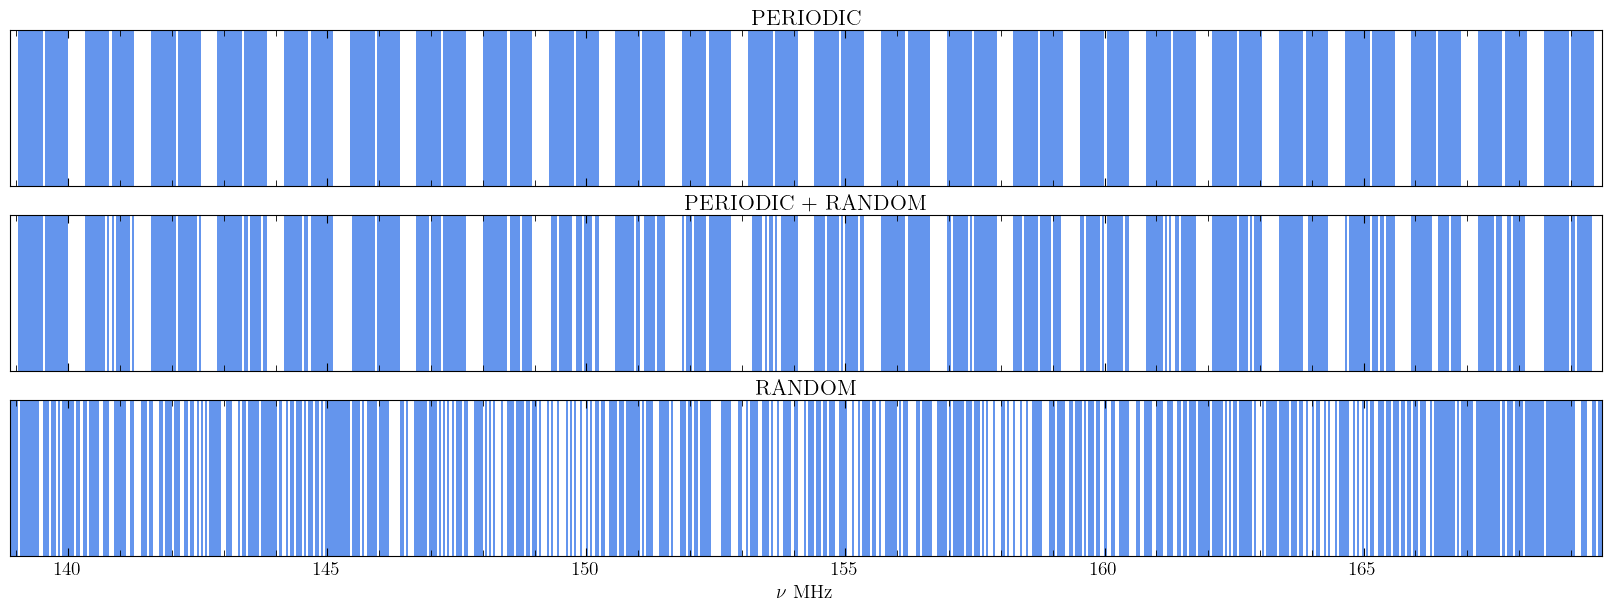

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# --------------------------------------------------
# Load data
# --------------------------------------------------
path = "data"
freq = np.load("nua.npy") / 1e6  # MHz

flag_periodic = np.load(f"{path}/PERIODIC.npy").astype(bool)
flag_prandom  = np.load(f"{path}/PERIODIC+RANDOM.npy").astype(bool)
flag_random   = np.load(f"{path}/RANDOM.npy").astype(bool)

# --------------------------------------------------
# Select central channels
# --------------------------------------------------
Nchan = freq.size
Nc = Nchan
i0 = Nchan // 2 - Nc // 2
i1 = Nchan // 2 + Nc // 2

freq_c = freq[i0:i1]

# --------------------------------------------------
# Frequency bin edges (needed for pcolormesh)
# --------------------------------------------------
df = np.diff(freq_c).mean()
freq_edges = np.concatenate([
    [freq_c[0] - df / 2],
    freq_c + df / 2
])

# --------------------------------------------------
# Figure: 3 × 1 panels
# --------------------------------------------------
fig, axes = plt.subplots(
    3, 1,
    figsize=(16, 6.0),
    sharex=True,
    constrained_layout=True,
    facecolor="white"
)

cases = [
    (flag_periodic[i0:i1],  r"{\rm PERIODIC}"),
    (flag_prandom[i0:i1],   r"{\rm PERIODIC + RANDOM}"),
    (flag_random[i0:i1],    r"{\rm RANDOM}"),
]

# Colormap for unflagged channels only
cmap_good = ListedColormap(["cornflowerblue"])

for ax, (flag, title) in zip(axes, cases):

    # --------------------------------------------------
    # Unflagged channels: solid blue
    # --------------------------------------------------
    good = np.ma.masked_where(~flag, flag)[np.newaxis, :]

    ax.imshow(
        good,
        aspect="auto",
        cmap=cmap_good,
        interpolation="nearest",
        extent=[freq_edges[0], freq_edges[-1], 0, 1]
    )

    # --------------------------------------------------
    # Flagged channels: hatched grey overlay
    # --------------------------------------------------
    flagged = (~flag).astype(int)[np.newaxis, :]

    # ax.pcolormesh(
    #     freq_edges,
    #     [0, 1],
    #     flagged,
    #     facecolor="red",
    # )

    ax.set_title(title, pad=4)

    # Remove y-axis completely
    ax.set_yticks([])
    ax.set_ylabel("")

    ax.tick_params(direction="in", top=True, right=True)

axes[-1].set_xlabel(r'$\rm{\nu\ MHz}$')

plt.savefig("plots/flagging.pdf", dpi=600, bbox_inches="tight")
# plt.show()


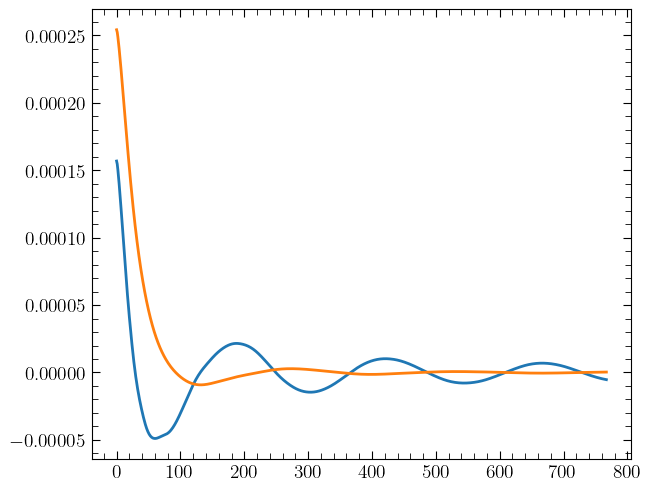

In [19]:

Omi = 1/(4*np.pi*r**2)
Omi = 1

plt.plot(cl21_discrete*Omi)
plt.plot(cl21)

